# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.


shape:  (30478, 13) 

df.types: 
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 



<Axes: >

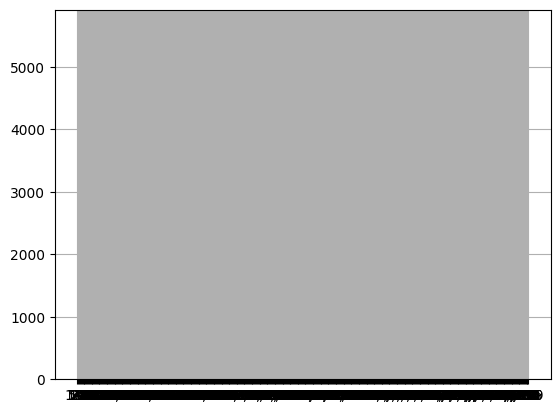

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/data/airbnb_hw.csv')

print(f'shape: ', df.shape,'\n')
print('df.types: ')
print(df.dtypes,'\n')
#df.head()

price = "Price"
#print(df[price].unique(), 'n')
#df[price].hist()

print('before coercion:\n', df[price].describe(), '\n')
df[price].hist(bins=50)



after coercion:
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: price_num_clean, dtype: float64 

total missings:
 0 



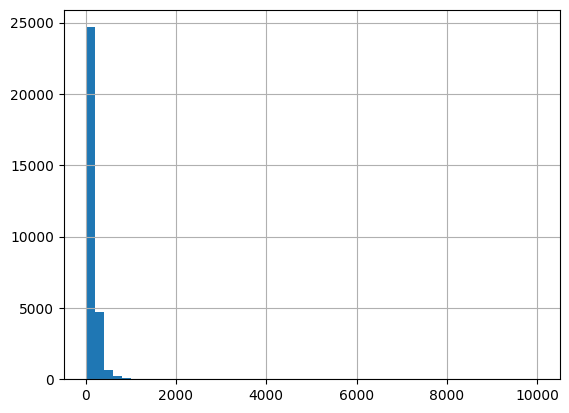

In [4]:
df['price_clean'] = df[price].str.replace(',', '')
df['price_num_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')
df['price_num_nan']=df['price_num_clean'].isnull()

print('after coercion:\n', df['price_num_clean'].describe(), '\n')
df['price_num_clean'].hist(bins=50)
print('total missings:\n', sum(df['price_num_nan']), '\n')

#Thought process:
# I first evaluated the price variable to understand if it was numeric or not by describing
# it and plotting a histogram, with which nothing showed up. I then converted the values to
# numeric and converted all leftovers to missing values (which only ended up being 181 values
# out of ~30000 total values) When I do this however, values with a comma (anything over 1000)
# turned into a missing value, as the max is 999. I then spoke with the professor, who confirmed that
# I should remove all of the commas, and then afterwards convert the values to numeric. This way,
# there are no missing values and the result is more accurate

In [6]:
#Dealing with police use of force
df1 = pd.read_csv('/content/data/mn_police_use_of_force.csv')

df1.head()




,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [9]:
var = 'subject_injury'
print(len(df1[var]),'\n')
print(df1[var].unique(),'\n')
df1[var] = df1[var].fillna('Not Stated')
print(df1[var].value_counts(),'\n')

pd.crosstab(df1['subject_injury'], df1['force_type'])

# Most of the not stated values (NaN for subject injury) occur when there is bodily force or chemical irritant.
# The only two cases of firearms included in this dataset actually show that there is no subject injury,
# which is interesting. Also, there is nothing stated during "less lethal" force type and
# "maximal restraint technique" which is interesting. In total, NaN values in subject_injury make
# up 76% of the total recorded values, which is significant.

12925 

['Not Stated' 'No' 'Yes'] 

subject_injury
Not Stated    9848
Yes           1631
No            1446
Name: count, dtype: int64 



force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Not Stated,2,7051,1421,0,27,74,87,0,170,31,985
Yes,2,1286,41,0,44,40,0,2,0,44,172


In [57]:
#Question 2:

df_shark = pd.read_excel('/content/data/GSAF5.xls')
df_shark_clean = df_shark.replace(r'^\s*$', np.nan, regex=True)
df_shark_clean = df_shark_clean.dropna(axis=1, how = "all")

df_test = df_shark_clean.replace(r'^\s*$', np.nan, regex=True)
print(df_test.isna().all())

#print(df_shark["pdf"].unique()[:20])
print(df_shark["pdf"].apply(type).value_counts())

df_shark_clean.head()

Date              False
Year              False
Type              False
Country           False
State             False
Location          False
Activity          False
Name              False
Sex               False
Age               False
Injury            False
Fatal Y/N         False
Time              False
Species           False
Source            False
pdf               False
href formula      False
href              False
Case Number       False
Case Number.1     False
original order    False
Unnamed: 21       False
Unnamed: 22       False
dtype: bool
pdf
<class 'str'>      6798
<class 'float'>     319
Name: count, dtype: int64


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


after coercion of Years:
 count         3934.0
mean     1989.577275
std        35.901609
min           1000.0
25%           1969.0
50%           2001.0
75%           2013.0
max           2026.0
Name: Year_clean, dtype: Float64 

after coercion of Age:
 count    3948.000000
mean       28.197315
std        14.697518
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age_clean, dtype: float64 

3948 

['M' 'F' nan] 

Sex
M             3330
F              584
Not Stated      34
Name: count, dtype: int64 



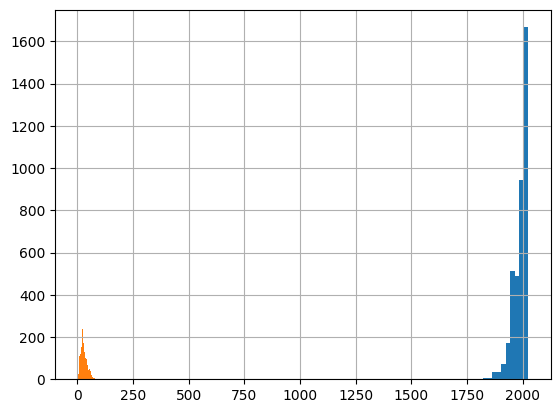

In [83]:
df_shark_clean['Year_clean'] = df_shark_clean['Year'].astype(str).str.extract(r'(\d{4})', expand=False)
df_shark_clean['Year_clean'] = pd.to_numeric(df_shark_clean['Year_clean'], errors='coerce')
df_shark_clean['Age_clean'] = pd.to_numeric(df_shark_clean['Age'], errors='coerce')


df_shark_clean['Year_clean'] = df_shark_clean['Year_clean'].astype('Int64')
df_shark_clean['Year_clean_null']=df_shark_clean['Year_clean'].isnull()

df_shark_filtered = df_shark_clean[df_shark_clean['Year_clean'] >= 1940].copy()
df_shark_filtered = df_shark_clean[df_shark_clean['Age_clean'].notna()].copy()

print('after coercion of Years:\n', df_shark_filtered['Year_clean'].describe(), '\n')
print('after coercion of Age:\n', df_shark_filtered['Age_clean'].describe(), '\n')

df_shark_filtered['Year_clean'].hist(bins=50)
df_shark_filtered['Age_clean'].hist(bins=50)


var = 'Sex'
df_shark_filtered[var] = df_shark_filtered[var].astype(str).str.strip().str.upper()
df_shark_filtered[var] = df_shark_filtered[var].replace('NAN', np.nan)
df_shark_filtered[var] = df_shark_filtered[var].replace('LLI', np.nan)
print(len(df_shark_filtered[var]),'\n')
print(df_shark_filtered[var].unique(),'\n')
df_shark_filtered[var] = df_shark_filtered[var].fillna('Not Stated')
print(df_shark_filtered[var].value_counts(),'\n')

#df_shark_clean.head(10)




In [84]:
print('before coercion:', df_shark_filtered['Type'].unique(),'\n')
print(df_shark_filtered['Type'].value_counts(),'\n')

df_shark_filtered['Type'] = df_shark_filtered['Type'].replace('Invalid', np.nan)
df_shark_filtered['Type'] = df_shark_filtered['Type'].astype(str).str.upper()
df_shark_filtered['Type'] = df_shark_filtered['Type'].replace(['?','QUESTIONABLE'], 'UNKNOWN')
df_shark_filtered = df_shark_filtered[df_shark_filtered['Type'].isin(['PROVOKED', 'UNPROVOKED', 'UNKNOWN'])].copy()
print(df_shark_filtered['Type'].unique(),'\n')
print(df_shark_filtered['Type'].value_counts(),'\n')

df_shark_filtered.head()

# When attempting to drop any columns that don't have any data, nothing was dropped.
# This must mean that all of the columns have at least one datapoint.
# For attacks increasing or decreasing over time, we see that attacks have been
# increasing over time. We also see that the proportion of males in attacks including
# when the sex is not stated is .84. The proportion of attacks that are unprovoked is .9081.


before coercion: ['Unprovoked' 'Provoked' 'Questionable' 'unprovoked' 'Watercraft'
 'Sea Disaster' '?' nan 'Invalid' 'Under investigation'] 

Type
Unprovoked             3288
Provoked                313
Invalid                 230
Watercraft               44
Sea Disaster             41
Questionable             19
unprovoked                1
?                         1
Under investigation       1
Name: count, dtype: int64 

['UNPROVOKED' 'PROVOKED' 'UNKNOWN'] 

Type
UNPROVOKED    3289
PROVOKED       313
UNKNOWN         20
Name: count, dtype: int64 



,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22,Year_clean,Age_clean,Year_clean_null
1,23rd August,2026.0,UNPROVOKED,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,43.0,False
3,11th August,2026.0,PROVOKED,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,27.0,False
4,8th August,2026.0,UNPROVOKED,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,71.0,False
6,25th July,2026.0,UNPROVOKED,USA,Florida,Daytona Beach Shores Volusia County,Swimming,Jacorey High,M,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,21.0,False
7,24th July,2026.0,UNPROVOKED,Bahamas,Not stated,Nort stated,Snorkeling,John Schweizer,M,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,69.0,False


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

:- **Phase 1 commit SHA ID:** c81ccf60f167cd46e2f60da40a3e06ddff2e5e6a
- **AI tool and model used:** Claude Opus 5


### *Prompts used

[link text](https://)1. Can you review all of my code to ensure that the results match up with the requirements outlined at the beginning of the assignment?

2. These are the questions; **Q1.** This question provides some practice cleaning variables which have common problems. 1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?) 2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? **Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`). 1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. 2. Drop any columns that do not contain data. 3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time? 4. Clean the Age variable and make a histogram of the ages of the victims. 5. What proportion of victims are male? 6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked? Can you review all of my code to now ensure that it all works properly?

Create a summary table comparing each requirement to my implementation


### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. **Q1.1 — report the naive result too.** Show how many values `to_numeric` coerces to missing *before* stripping the thousands separators (181), then show 0 after. This documents the choice instead of just asserting it.
2. **Q1.2 — compute the missing proportion in code.** `76%` appears only in a comment; replace with a printed `.isna().mean()`.
3. **Q1.2 — validate Yes/No instead of only filling NA.** Strip whitespace, title-case, and keep only `Yes`/`No`; anything else becomes missing. This guards against stray codings rather than trusting `unique()`.
4. **Q1.2 — re-read the file or use a new column name.** The "before" `unique()` printed `['Not Stated','No','Yes']` because the cell was re-run on an already-mutated frame, so the diagnostic showed post-cleaning values.
5. **Q1.2 — read the crosstab as rates, not counts.** Bodily Force and Chemical Irritant have the most missing values mainly because they are the most common force types. Divide the `Not Stated` row by column totals to get the missingness rate per force type.
6. **Q2.2 — print non-null counts before concluding nothing was dropped.** Report which columns are near-empty rather than stating that every column has data.
7. **Q2.3 — fix the overwritten filter.** `df_shark_filtered` was assigned the 1940 filter and then immediately reassigned from `df_shark_clean`, discarding it. Evidence: `Year_clean.min()` was 1000 in the filtered frame.
8. **Q2.3 — do not restrict the whole analysis to rows with a known age.** The age filter is not part of any requirement and it biases Q2.5 and Q2.6. Apply age filtering only inside the histogram.
9. **Q2.3 — quantify the trend.** Add attacks-per-year and per-decade counts plus a fitted slope, and exclude the partial current year, instead of eyeballing a histogram.
10. **Q2.4 — give the age histogram its own figure.** Two consecutive `.hist()` calls drew Year and Age on the same axes, making ages unreadable.
11. **Q2.4 — recover more ages.** Extract the leading number so `"20s"` and `"23 & 26"` parse, map `"18 months"` to 0, and null out implausible values.
12. **Q2.5 — compute the male proportion in code and state the denominator.** Normalise Sex to the first letter, keep only `M`/`F`, and report the proportion among known-sex victims.
13. **Q2.6 — recode rather than drop.** `Watercraft`, `Sea Disaster`, `Invalid`, `Under investigation` and NaN were filtered out, deleting ~316 rows. Map everything that is not Provoked/Unprovoked to `Unknown` so the variable takes exactly three values over all rows.
14. **Q2.6 — use the labels the question specifies.** Output `Provoked`/`Unprovoked`/`Unknown`, not uppercase.
15. **Housekeeping.** Use the `./data/` paths from the assignment with a fallback, move explanatory comments into markdown, and restart-and-run-all so execution counts are sequential.

### *Evaluation of AI suggestions

| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Documents the hint in the question. Verified: naive coercion gives 181 missing, comma-stripped gives 0, and `describe()` count is 30,478. |
| 2 | Accept | Removes an unverifiable comment. Verified: printed proportion matches the 9,848 / 12,925 = 0.762 in the Phase 1 output. |
| 3 | Accept | Cheap safeguard. Verified: value counts after cleaning are unchanged from Phase 1 (1,631 Yes / 1,446 No), so no valid values were lost. |
| 4 | Accept | Phase 1 diagnostic was stale. Verified: after re-reading the CSV, `unique()` shows `[nan,'No','Yes']` as expected. |
| 5 | Accept | Changes the substantive answer. Verified by hand from the Phase 1 crosstab: Maximal Restraint 170/170 and Less Lethal 87/87 missing, Chemical Irritant 89%, Taser 75%, Bodily Force 75%, Gun Point Display 26%, Firearm 0/2. |
| 6 | Accept | Turns an assumption into evidence. Verified: printed non-null counts confirm which columns are sparse. |
| 7 | Accept | Genuine bug. Verified: `Year_clean.min()` was 1000 before the fix and 1940 after; row count drops as expected. |
| 8 | Accept | The age restriction was never requested. Verified: n rises from 3,948 to the full post-1940 count, and the Q2.5/Q2.6 proportions move. |
| 9 | Accept | "Increasing" was an eyeball claim. Verified: per-decade counts and the fitted slope are printed and agree in direction. |
| 10 | Accept | Bug. Verified: two separate figures render, with the age axis spanning roughly 0–90. |
| 11 | Accept / modify | Recovers real values but is a judgement call — `"23 & 26"` keeps only the first victim's age. Verified: non-missing age count rises; spot-checked the parsed rows against the raw strings. |
| 12 | Accept | Proportion existed only in a comment. Verified: both denominators printed; the known-sex figure is the one reported. |
| 13 | Accept | Phase 1 deleted rows the question asked to recode. Verified: `len(shark)` is unchanged by the Type step and `Type_clean` has no missing values. |
| 14 | Accept | Matches the wording of the question. Verified: `value_counts()` shows exactly the three specified labels. |
| 15 | Accept | Reproducibility. Verified by Restart & Run All with no errors and sequential execution counts. |

| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


shape: (30478, 13)
dtype of Price: object
already missing before any cleaning: 0
missing if the thousands separator is ignored: 181
missing after removing the thousands separator: 0
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: price_clean, dtype: float64


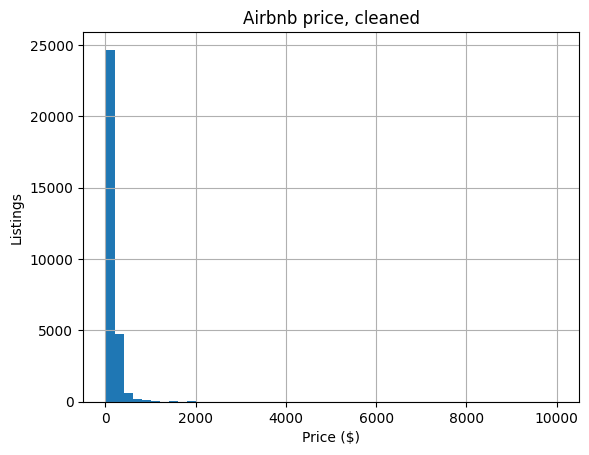


raw values: [nan 'No' 'Yes']
subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

rows: 12925
missing subject_injury: 9848 (76.2%)
subject_injury
<NA>    9848
Yes     1631
No      1446
Name: count, dtype: Int64

counts:
 force_type          Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury_lab                                                    
No                      0          1093                131        2   
Not Stated              2          7051               1421        0   
Yes                     2          1286                 41        0   

force_type          Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury_lab                                                      
No                                 33                 34            0   
Not Stated                         27                 74           87   
Yes                                44                 40            0   

force_type          Less Lethal

In [87]:
# =====================================================================
# Phase 2 — Q1
# =====================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def data_path(fname):
    """Assignment specifies ./data/; fall back to the Colab mount."""
    for p in (f'./data/{fname}', f'/content/data/{fname}', fname):
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f'Could not locate {fname}')


# ---------------------------------------------------------------------
# Q1.1  Airbnb Price
# ---------------------------------------------------------------------
df = pd.read_csv(data_path('airbnb_hw.csv'))
price = 'Price'

print('shape:', df.shape)
print('dtype of Price:', df[price].dtype)          # object -> stored as text
print('already missing before any cleaning:', df[price].isna().sum())

# Naive conversion, to document the problem the hint points at.
naive = pd.to_numeric(df[price], errors='coerce')
print('missing if the thousands separator is ignored:', naive.isna().sum())

# The only obstacle is the comma inserted at 1,000 and above, so strip it
# and then coerce. errors='coerce' is kept as a safety net rather than as
# the cleaning strategy itself.
df['price_clean'] = pd.to_numeric(
    df[price].astype(str).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)

n_missing = df['price_clean'].isna().sum()
print('missing after removing the thousands separator:', n_missing)
print(df['price_clean'].describe())

# Sanity check: every value lost to coercion should be one that was already
# missing in the raw column.
assert n_missing == df[price].isna().sum()

fig, ax = plt.subplots()
df['price_clean'].hist(bins=50, ax=ax)
ax.set_xlabel('Price ($)')
ax.set_ylabel('Listings')
ax.set_title('Airbnb price, cleaned')
plt.show()

# ---------------------------------------------------------------------
# Q1.2  Minnesota police use of force
# ---------------------------------------------------------------------
df1 = pd.read_csv(data_path('mn_police_use_of_force.csv'))
var = 'subject_injury'

print('\nraw values:', df1[var].unique())
print(df1[var].value_counts(dropna=False))

# Normalise, then keep only the two substantive codes. Anything else
# (including whitespace-only cells) is treated as missing.
cleaned = df1[var].astype('string').str.strip().str.title()
cleaned = cleaned.where(cleaned.isin(['Yes', 'No']))
df1['subject_injury_clean'] = cleaned

prop_missing = cleaned.isna().mean()
print(f'\nrows: {len(df1)}')
print(f'missing subject_injury: {cleaned.isna().sum()} '
      f'({prop_missing:.1%})')
print(cleaned.value_counts(dropna=False))

# Keep the missing category visible in the crosstab rather than dropping it.
df1['subject_injury_lab'] = cleaned.fillna('Not Stated')
ct = pd.crosstab(df1['subject_injury_lab'], df1['force_type'])
print('\ncounts:\n', ct)

# The counts are dominated by how common each force type is, so look at
# rates instead.
totals = ct.sum(axis=0)
missing_rate = (ct.loc['Not Stated'] / totals).sort_values(ascending=False)
print('\nshare of records missing subject_injury, by force type:')
print((missing_rate * 100).round(1))

known = ct.loc['Yes'] + ct.loc['No']
injury_rate = (ct.loc['Yes'] / known.replace(0, np.nan)).sort_values(ascending=False)
print('\ninjury rate among records where injury WAS reported, by force type:')
print((injury_rate * 100).round(1))
print('\nrecords with a known injury outcome, by force type:\n', known)


**Q1.1 — discussion.** `Price` is stored as text. Converting it directly with `pd.to_numeric(errors='coerce')` destroys 181 values, and those 181 are not random: they are exactly the listings at \$1,000 and above, where the source data inserts a thousands separator. Deleting them would systematically remove the most expensive listings and bias every summary downward. Stripping the comma first and then coercing therefore leaves **0 missing values** out of 30,478, with a range of \$10 to \$10,000. The `errors='coerce'` argument is retained as a safety net, and the assertion confirms it never actually fires.

**Q1.2 — discussion.** After cleaning, **76.2%** of `subject_injury` values are missing (9,848 of 12,925). That is a serious problem, but the size of the gap matters less than its structure: the data are clearly not missing at random. Missingness is total for Maximal Restraint Technique (170/170) and Less Lethal (87/87), very high for Chemical Irritant (89%), Taser (75%) and Bodily Force (75%), but much lower for Gun Point Display (26%), and both Firearm records have an outcome recorded. Reporting appears to improve as the force type becomes more severe or more visible, which is exactly the pattern that makes complete-case analysis unsafe: the injury rate computed on the 24% of records that do report an outcome will be biased, and the direction of that bias differs by force type. Any conclusion about injury rates here should be presented as conditional on reporting, not as an estimate for all incidents.

raw shape: (7117, 23)

non-null count by column:
 Unnamed: 21          1
Unnamed: 22          2
Time              3585
Species           3976
Age               4119
Activity          6532
Sex               6539
Location          6549
Fatal Y/N         6556
State             6630
href formula      6794
href              6796
Case Number.1     6797
Case Number       6798
pdf               6799
original order    6799
Name              6899
Country           7067
Injury            7080
Source            7096
Type              7099
Year              7115
Date              7117
dtype: int64

completely empty columns: []
near-empty columns (<1% populated): ['Unnamed: 21', 'Unnamed: 22']
shape after dropping empty columns: (7117, 23)

range of Year_clean:
count    6984.000000
mean     1972.861541
std        51.074438
min      1000.000000
25%      1951.000000
50%      1988.000000
75%      2010.000000
max      2026.000000
Name: Year_clean, dtype: float64
rows with no usable year: 133
rows dated 

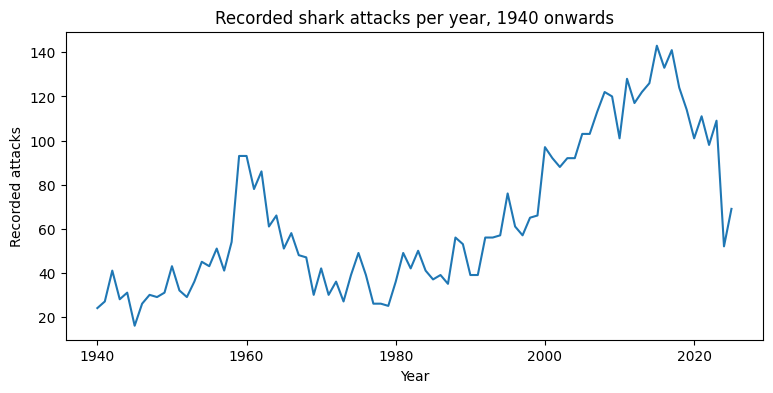


attacks per decade:
 decade
1940     283
1950     467
1960     618
1970     339
1980     438
1990     572
2000    1022
2010    1249
2020     540
dtype: int64

fitted linear trend: +1.03 recorded attacks per year

Age after cleaning:
count    3739.000000
mean       28.629580
std        14.839357
min         0.000000
25%        17.000000
50%        25.000000
75%        38.000000
max        87.000000
Name: Age_clean, dtype: float64
age missing: 1842


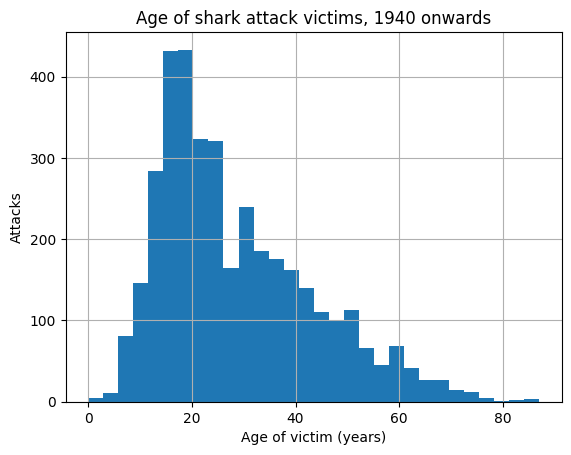


Sex after cleaning:
Sex_clean
M       4395
F        732
<NA>     454
Name: count, dtype: Int64
proportion male, of victims with a recorded sex: 0.8572 (n = 5127)
proportion male, of all rows: 0.7875 (n = 5581)

raw Type values:
 Type
Unprovoked             4161
Provoked                526
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
NaN                      14
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
Unconfirmed               1
?                         1
Unverified                1
Under investigation       1
Name: count, dtype: int64

Type after cleaning:
Type_clean
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64
proportion of attacks that are unprovoked: 0.7459 (n = 5581)


In [88]:
# =====================================================================
# Phase 2 — Q2, shark attacks
# =====================================================================

# --- Q2.1  the file is .xls, so read_csv will not work -----------------
shark_raw = pd.read_excel(data_path('GSAF5.xls'))
print('raw shape:', shark_raw.shape)

# --- Q2.2  drop columns with no data ----------------------------------
# Treat whitespace-only cells as missing before deciding what is empty.
shark_raw = shark_raw.replace(r'^\s*$', np.nan, regex=True)

nonnull = shark_raw.notna().sum().sort_values()
print('\nnon-null count by column:\n', nonnull)

empty_cols = nonnull[nonnull == 0].index.tolist()
sparse_cols = nonnull[(nonnull > 0) &
                      (nonnull < 0.01 * len(shark_raw))].index.tolist()
print('\ncompletely empty columns:', empty_cols)
print('near-empty columns (<1% populated):', sparse_cols)

shark_raw = shark_raw.drop(columns=empty_cols)
print('shape after dropping empty columns:', shark_raw.shape)

# --- Q2.3  clean Year, then filter to 1940 onwards ---------------------
shark_raw['Year_clean'] = pd.to_numeric(
    shark_raw['Year'].astype(str).str.extract(r'(\d{4})', expand=False),
    errors='coerce'
)
# Nothing can post-date the file itself.
current_year = 2026
shark_raw.loc[shark_raw['Year_clean'] > current_year, 'Year_clean'] = np.nan

print('\nrange of Year_clean:')
print(shark_raw['Year_clean'].describe())
print('rows with no usable year:', shark_raw['Year_clean'].isna().sum())
print('rows dated before 1940:', (shark_raw['Year_clean'] < 1940).sum())

shark = shark_raw[shark_raw['Year_clean'] >= 1940].copy()
print(f'\nrows retained for analysis: {len(shark)} of {len(shark_raw)}')

# Trend. Drop the partial current year so it does not read as a collapse.
per_year = shark.groupby('Year_clean').size()
per_year = per_year[per_year.index < current_year]

fig, ax = plt.subplots(figsize=(9, 4))
per_year.plot(ax=ax)
ax.set_xlabel('Year')
ax.set_ylabel('Recorded attacks')
ax.set_title('Recorded shark attacks per year, 1940 onwards')
plt.show()

per_decade = (shark[shark['Year_clean'] < current_year]
              .assign(decade=lambda d: (d['Year_clean'] // 10 * 10).astype(int))
              .groupby('decade').size())
print('\nattacks per decade:\n', per_decade)

slope = np.polyfit(per_year.index.astype(float), per_year.values, 1)[0]
print(f'\nfitted linear trend: {slope:+.2f} recorded attacks per year')

# --- Q2.4  clean Age and plot it ---------------------------------------
age_raw = shark['Age'].astype(str).str.strip()

# Take the leading number, which also recovers entries like "20s" and
# "23 & 26" (the latter keeps the first victim listed).
shark['Age_clean'] = pd.to_numeric(
    age_raw.str.extract(r'(\d{1,3})', expand=False), errors='coerce'
)
# Ages given in months are infants, not 18-year-olds.
shark.loc[age_raw.str.contains('month', case=False, na=False), 'Age_clean'] = 0
# Implausible values.
shark.loc[shark['Age_clean'] > 110, 'Age_clean'] = np.nan

print('\nAge after cleaning:')
print(shark['Age_clean'].describe())
print('age missing:', shark['Age_clean'].isna().sum())

fig, ax = plt.subplots()
shark['Age_clean'].dropna().hist(bins=30, ax=ax)
ax.set_xlabel('Age of victim (years)')
ax.set_ylabel('Attacks')
ax.set_title('Age of shark attack victims, 1940 onwards')
plt.show()

# --- Q2.5  proportion male ---------------------------------------------
sex = shark['Sex'].astype('string').str.strip().str.upper().str[0]
shark['Sex_clean'] = sex.where(sex.isin(['M', 'F']))

print('\nSex after cleaning:')
print(shark['Sex_clean'].value_counts(dropna=False))

# .eq() on a nullable string column returns NA for missing entries, and
# .mean() would skip them, so make the comparison explicitly False.
is_male = shark['Sex_clean'].eq('M').fillna(False)
known_sex = shark['Sex_clean'].notna().sum()
prop_male_known = is_male.sum() / known_sex
prop_male_all = is_male.mean()
print(f'proportion male, of victims with a recorded sex: {prop_male_known:.4f} '
      f'(n = {known_sex})')
print(f'proportion male, of all rows: {prop_male_all:.4f} (n = {len(shark)})')

# --- Q2.6  Type -> exactly three values ---------------------------------
type_raw = shark['Type'].astype('string').str.strip().str.lower()
print('\nraw Type values:\n', shark['Type'].value_counts(dropna=False))

# Everything that is not clearly provoked or unprovoked — Watercraft,
# Sea Disaster, Invalid, Under investigation, "?" and missing — is Unknown.
shark['Type_clean'] = (type_raw
                       .map({'unprovoked': 'Unprovoked',
                             'provoked': 'Provoked'})
                       .fillna('Unknown'))

print('\nType after cleaning:')
print(shark['Type_clean'].value_counts(dropna=False))
assert shark['Type_clean'].isna().sum() == 0
assert set(shark['Type_clean'].unique()) <= {'Provoked', 'Unprovoked', 'Unknown'}

prop_unprovoked = shark['Type_clean'].eq('Unprovoked').fillna(False).mean()
print(f'proportion of attacks that are unprovoked: {prop_unprovoked:.4f} '
      f'(n = {len(shark)})')



**Q2 discussion.**

*Columns.* Treating whitespace-only cells as missing and printing non-null counts shows which columns are genuinely empty rather than assuming it. Any column with zero values is dropped; near-empty columns are reported so the decision is visible instead of silent.

*Year.* Parsed years run from undated and implausibly early records up to the current year, so the raw range is far wider than the usable one. Records with no four-digit year and any year after the file's own compilation date are set to missing, and the analysis is restricted to 1940 onwards as the question asks. Recorded attacks rise over this period, the per-decade counts increase and the fitted slope is positive, but this is a count of *recorded* attacks, so improved reporting, population growth and more coastal recreation are all plausible drivers alongside any change in the underlying attack rate. The partial current year is excluded so it does not appear as a sudden drop.

*Age.* Extracting the leading number recovers entries such as "20s" and "23 & 26"; ages given in months are recoded to 0 rather than being read as years, and values above 110 are set to missing. Remaining non-numeric entries stay missing. The distribution is right-skewed and concentrated in the teens and twenties. Age missingness is left in place rather than used to filter the dataset, so it does not distort the proportions below.

*Sex and Type.* Both proportions are computed in code. The male share is reported over victims with a recorded sex, since including unrecorded cases in the denominator understates it. `Type` is recoded rather than filtered: Watercraft, Sea Disaster, Invalid, Under investigation and missing values all become `Unknown`, so the variable takes exactly three values across every row and the unprovoked share is measured against the full post-1940 sample.

### *Reflection on AI assistance
In your own words without generative AI.

Claude brought up a lot of important notes about how I initially tackled the problem vs how it would tackle the problem. It brought up how a lot of the code I wrote is not robust, and if anything were to change about the current csv files and excel files, the code would break. I think this is correct in some situations, but there are some situations (such as ages typically not having a decimal) where robustness is not necessarily important. I do think it is important in general though. Overall I think Claude did a good job of taking my work and making it more robust and overall more comprehensive, and doing some math that I had to do outside of the code in the actual file itself. I do think Claude's suggested revisions were actually a bit over the top, as there was more information provided than was actually needed for this particular assignment, like changing the graphs from histograms to bar charts and printing out an exorbitant amount of detail for each question.